In [5]:
import pandas as pd
import numpy as np
import os

In [6]:
name_result = "results_gemini-3.1-pro-preview_python_zero.csv"
file_path = f"../output/results/{name_result}"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Arquivo carregado com sucesso!")
else:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado. Verifique se o judge já terminou de rodar.")

Arquivo carregado com sucesso!


In [8]:
df['is_ac'] = df['judge_predict'] == 'AC'
df['test_case_accuracy'] = np.where(df['total_test_cases'] > 0, 
                                    df['AC'] / df['total_test_cases'], 0)

benchmark = df.groupby('level_to_llm').agg(
    qtd_problemas=('question_name', 'count'),
    taxa_sucesso_ac=('is_ac', 'mean'),
    acuracia_testes=('test_case_accuracy', 'mean'),
    tempo_geracao=('llm_code_creation_time', 'mean'),
    tempo_exec_max=('execution_time', 'max'),
    erros_logica=('WA', 'sum'),
    erros_runtime=('RE', 'sum'),
    no_code=('judge_predict', lambda x: (x == 'NO CODE').sum())
).reset_index()

ordem_niveis = {'FACIL': 0, 'MEDIO': 1, 'DIFICIL': 2}
benchmark['ordem'] = benchmark['level_to_llm'].map(ordem_niveis)
benchmark = benchmark.sort_values('ordem').drop('ordem', axis=1)

benchmark['taxa_sucesso_ac'] = (benchmark['taxa_sucesso_ac'] * 100).map('{:.1f}%'.format)
benchmark['acuracia_testes'] = (benchmark['acuracia_testes'] * 100).map('{:.1f}%'.format)
benchmark['tempo_geracao'] = benchmark['tempo_geracao'].map('{:.2f}s'.format)
benchmark['tempo_exec_max'] = benchmark['tempo_exec_max'].map('{:.3f}s'.format)

benchmark.columns = [
    'Nível', 'Qtd', 'Sucesso (AC)', 'Acurácia Testes', 
    'Tempo Geração', 'Gargalo Exec', 'Soma WA', 'Soma RE', 'No Code'
]

print(f"### BENCHMARKING POR NÍVEL DE DIFICULDADE ###")
print(benchmark.to_string(index=False))

### BENCHMARKING POR NÍVEL DE DIFICULDADE ###
  Nível  Qtd Sucesso (AC) Acurácia Testes Tempo Geração Gargalo Exec  Soma WA  Soma RE  No Code
  FACIL    8        87.5%           87.5%        24.28s       0.274s        4       16        0
DIFICIL    5        60.0%           60.0%       305.73s       2.892s        0        0        2


/tmp/ipykernel_417009/3349392799.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


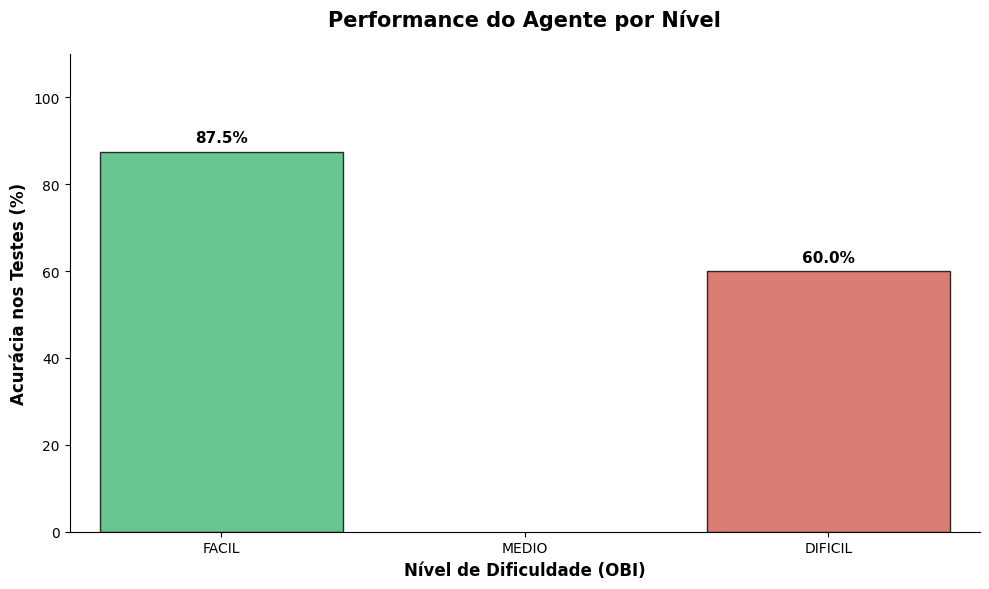

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparação dos dados
plot_data = benchmark.copy()

# Garante que as colunas sejam numéricas (remove o % se existir)
for col in ['Sucesso (AC)', 'Acurácia Testes']:
    if plot_data[col].dtype == 'object':
        plot_data[col] = plot_data[col].str.replace('%', '').replace('nan', '0').astype(float)

# FORÇAR OS NÍVEIS: Isso garante que 'MEDIO' apareça mesmo que os dados sejam zero
niveis_fixos = ['FACIL', 'MEDIO', 'DIFICIL']
plot_data['Nível'] = pd.Categorical(plot_data['Nível'], categories=niveis_fixos, ordered=True)

# --- Configuração do Gráfico ---
plt.style.use('seaborn-v0_8-muted')
fig, ax1 = plt.subplots(figsize=(10, 6))

# Cores: Verde, Amarelo, Vermelho
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

# 1. Gráfico de Barras apenas (Linha removida)
# Adicionamos 'hue' para evitar avisos de versões futuras do Seaborn
sns.barplot(
    x='Nível', 
    y='Acurácia Testes', 
    data=plot_data, 
    palette=colors, 
    ax=ax1, 
    edgecolor='black',
    alpha=0.8
)

# Customização
ax1.set_ylim(0, 110)
ax1.set_ylabel('Acurácia nos Testes (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Nível de Dificuldade (OBI)', fontsize=12, fontweight='bold')
plt.title('Performance do Agente por Nível', fontsize=15, pad=20, fontweight='bold')

# Adicionar rótulos de dados (Data Labels)
for p in ax1.patches:
    height = p.get_height()
    # Se o valor for NaN ou 0, garantimos que escreva 0.0%
    label_text = f'{height:.1f}%' if not np.isnan(height) else "0.0%"
    ax1.annotate(label_text, 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='center', 
                 xytext=(0, 10), 
                 textcoords='offset points',
                 fontweight='bold',
                 fontsize=11)

sns.despine()
plt.tight_layout()

# Salvar opcionalmente
# plt.savefig('benchmark_agente.png', dpi=300)

plt.show()

In [2]:
!pip install seaborn